# Assignment 20: Forecasting Exchange Rates using Time Series Analysis
##### Author: Md Ashhar Farooqui
##### Date: 26-07-2025

# Part 1: Data Preparation and Exploration

**Data Loading:** Load the exchange_rate.csv dataset and parse the date column appropriately.

**Initial Exploration:** Plot the time series for currency to understand their trends, seasonality, and any anomalies.

**Data Preprocessing:** Handle any missing values or anomalies identified during the exploration phase.

In [14]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [34]:
# 1. Data Loading
df = pd.read_csv('exchange_rate.csv', parse_dates=['date'], dayfirst=True)
df.head()

,date,Ex_rate
0,1990-01-01,0.7855
1,1990-01-02,0.7818
2,1990-01-03,0.7867
3,1990-01-04,0.7860
4,1990-01-05,0.7849


In [35]:
df.info()  # Display information about the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   date     7588 non-null   datetime64[ns]
 1   Ex_rate  7588 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 118.7 KB


In [36]:
df.describe()  # Get a statistical summary of the dataset

,date,Ex_rate
count,7588,7588.000000
mean,2000-05-21 12:00:00,0.776974
min,1990-01-01 00:00:00,0.483297
25%,1995-03-12 18:00:00,0.701422
50%,2000-05-21 12:00:00,0.761377
75%,2005-07-31 06:00:00,0.873477
max,2010-10-10 00:00:00,1.102536
std,NaN,0.136620


In [37]:
df.columns = ['Date', 'USD_AUD']
df.set_index('Date', inplace=True)
df = df.sort_index()

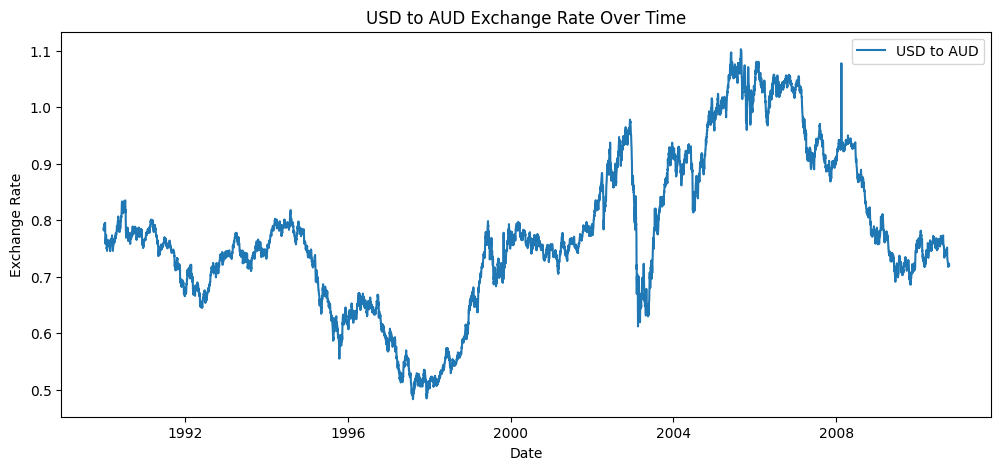

In [38]:
# 2. Initial Exploration
plt.figure(figsize=(12,5))
plt.plot(df['USD_AUD'], label='USD to AUD')
plt.title('USD to AUD Exchange Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.show()

In [39]:
# Check for missing values and basic stats
print(df['USD_AUD'].isnull().sum())
print(df['USD_AUD'].describe())

0
count    7588.000000
mean        0.776974
std         0.136620
min         0.483297
25%         0.701422
50%         0.761377
75%         0.873477
max         1.102536
Name: USD_AUD, dtype: float64


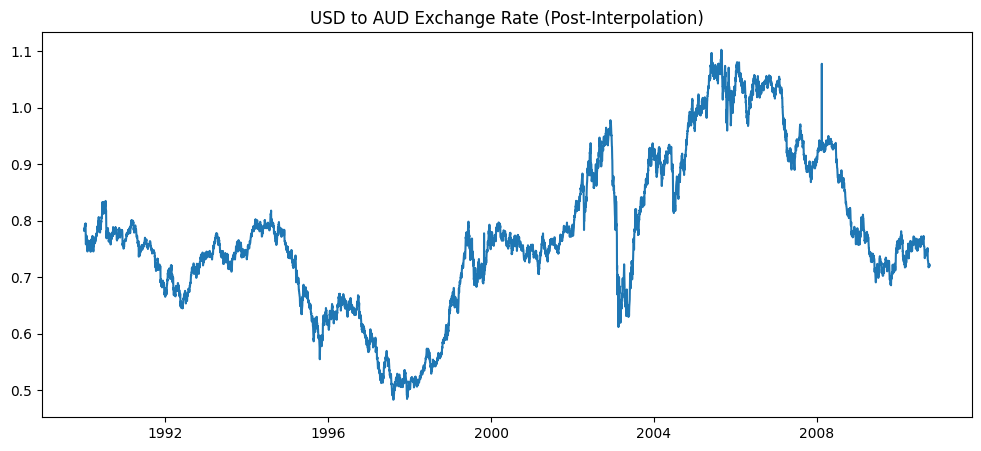

In [40]:
# Interpolate missing values if any (now index is DatetimeIndex)
df['USD_AUD'] = df['USD_AUD'].interpolate(method='time')

# Outlier detection (visual/manual for now)
plt.figure(figsize=(12,5))
plt.plot(df['USD_AUD'])
plt.title('USD to AUD Exchange Rate (Post-Interpolation)')
plt.show()

# Part 2: Model Building - ARIMA

**Parameter Selection for ARIMA:** Utilize ACF and PACF plots to estimate initial parameters (p, d, q) for the ARIMA model for one or more currency time series.

**Model Fitting:** Fit the ARIMA model with the selected parameters to the preprocessed time series.

**Diagnostics:** Analyze the residuals to ensure there are no patterns that might indicate model inadequacies.

**Forecasting:** Perform out-of-sample forecasting and visualize the predicted values against the actual values.

ADF Statistic: -1.6649941807381528
p-value: 0.4492327353597901


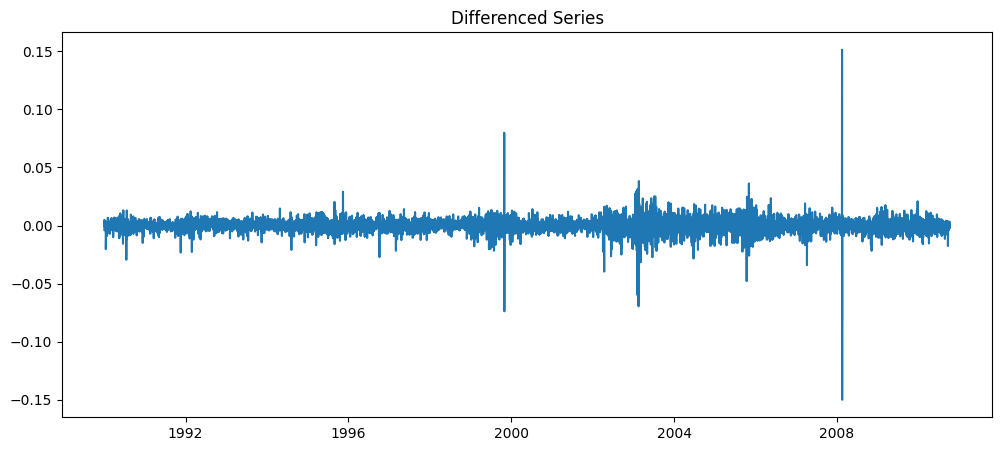

In [41]:
# 1. Stationarity Check and Differencing
# Augmented Dickey-Fuller test
result = adfuller(df['USD_AUD'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])

# If not stationary, difference the series
if result[1] > 0.05:
    df['USD_AUD_diff'] = df['USD_AUD'].diff().dropna()
    series_to_use = df['USD_AUD_diff'].dropna()
    d = 1
else:
    series_to_use = df['USD_AUD']
    d = 0

plt.figure(figsize=(12,5))
plt.plot(series_to_use)
plt.title('Differenced Series' if d==1 else 'Original Series')
plt.show()

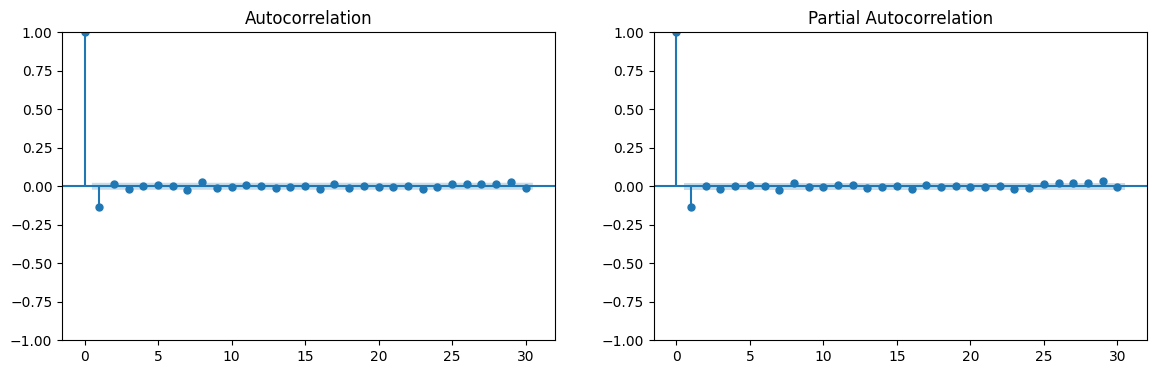

In [42]:
# 2. ACF and PACF for Parameter Selection
fig, axes = plt.subplots(1,2, figsize=(14,4))
plot_acf(series_to_use, ax=axes[0], lags=30)
plot_pacf(series_to_use, ax=axes[1], lags=30)
plt.show()

# Based on plots, select p and q (example: p=1, q=1)
p = 1
q = 1

In [43]:
# 3. Model Fitting
# Split into train/test for out-of-sample forecasting
train_size = int(len(df)*0.8)
train, test = df['USD_AUD'][:train_size], df['USD_AUD'][train_size:]

In [44]:
# Fit ARIMA
arima_model = ARIMA(train, order=(p, d, q))
arima_result = arima_model.fit()
print(arima_result.summary())

c:\py-3.13.3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\py-3.13.3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\py-3.13.3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                USD_AUD   No. Observations:                 6070
Model:                 ARIMA(1, 1, 1)   Log Likelihood               22719.046
Date:                Sat, 26 Jul 2025   AIC                         -45432.092
Time:                        19:33:02   BIC                         -45411.959
Sample:                    01-01-1990   HQIC                        -45425.104
                         - 08-14-2006                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5972      0.062     -9.648      0.000      -0.719      -0.476
ma.L1          0.5398      0.064      8.430      0.000       0.414       0.665
sigma2      3.281e-05   1.95e-07    168.198      0.0

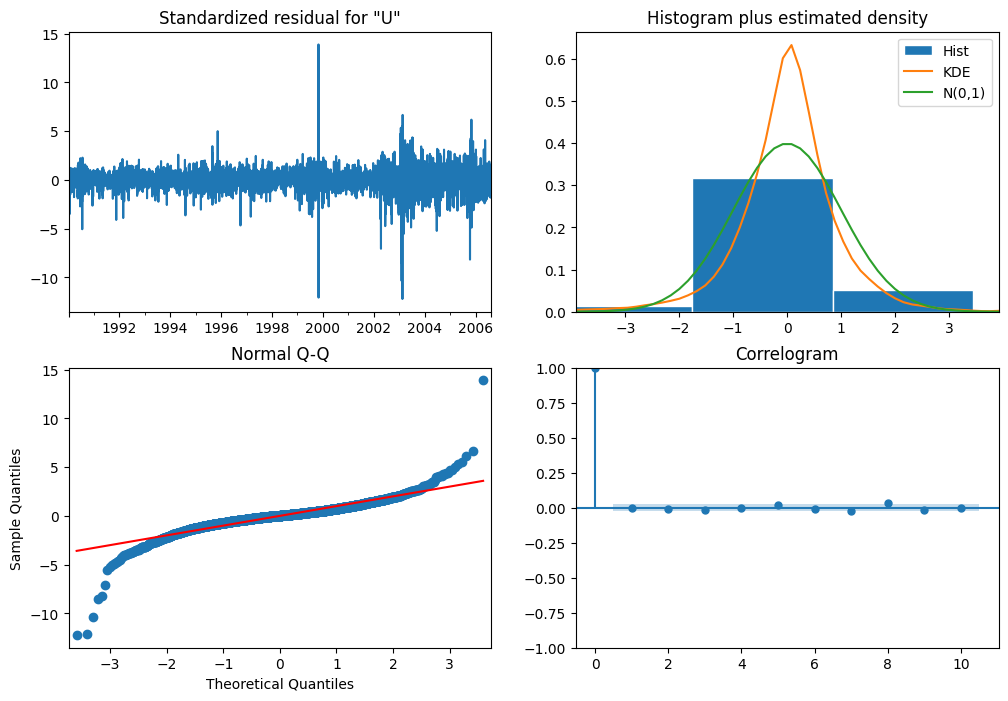

In [45]:
# 4. Diagnostics
arima_result.plot_diagnostics(figsize=(12,8))
plt.show()

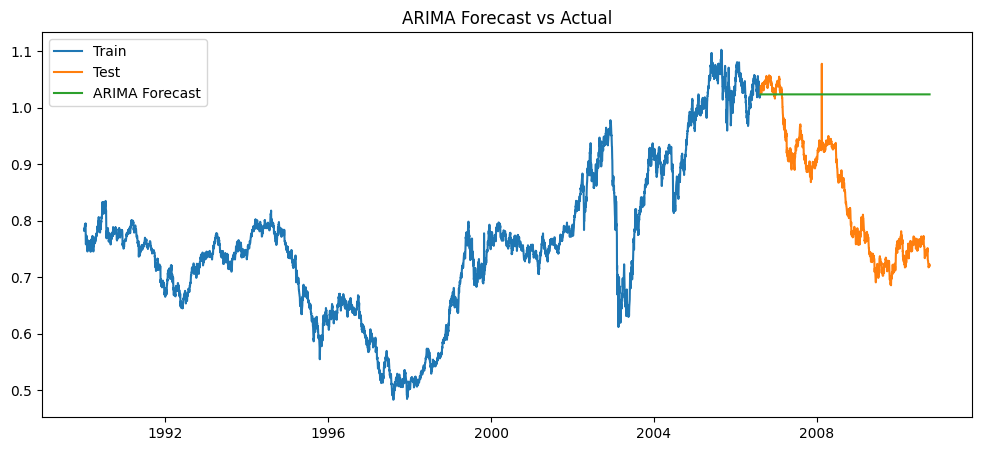

In [46]:
# 5. Forecasting
# Forecast for the length of the test set
forecast = arima_result.forecast(steps=len(test))
plt.figure(figsize=(12,5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(test.index, forecast, label='ARIMA Forecast')
plt.legend()
plt.title('ARIMA Forecast vs Actual')
plt.show()

# Part 3: Model Building - Exponential Smoothing

**Model Selection:** Depending on the time series characteristics, choose an appropriate Exponential Smoothing model (Simple, Holt’s Linear, or Holt-Winters).

**Parameter Optimization:** Use techniques such as grid search or AIC to find the optimal parameters for the smoothing levels and components.

**Model Fitting and Forecasting:** Fit the chosen Exponential Smoothing model and forecast future values. Compare these forecasts visually with the actual data.

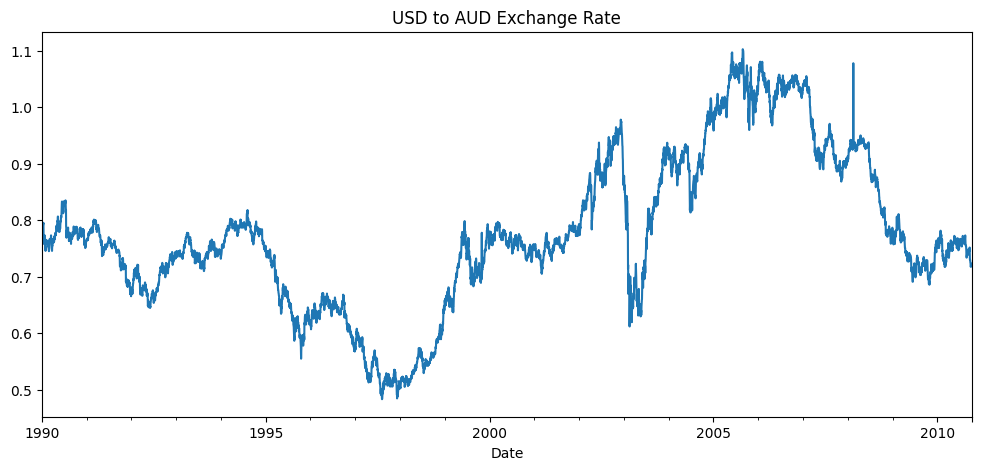

In [47]:
# 1. Model Selection
# Plot to check for trend/seasonality
decompose_plot = df['USD_AUD'].plot(figsize=(12,5), title='USD to AUD Exchange Rate')
plt.show()

In [48]:
# If trend but no clear seasonality, use Holt's Linear
# If both, use Holt-Winters (additive/multiplicative)
# Here, let's use Holt's Linear for simplicity

# 2. Parameter Optimization (let the model optimize alpha/beta)
hw_model = ExponentialSmoothing(train, trend='add', seasonal=None)
hw_result = hw_model.fit(optimized=True)
print(hw_result.summary())

c:\py-3.13.3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                       ExponentialSmoothing Model Results                       
Dep. Variable:                  USD_AUD   No. Observations:                 6070
Model:             ExponentialSmoothing   SSE                              0.199
Optimized:                         True   AIC                         -62655.290
Trend:                         Additive   BIC                         -62628.446
Seasonal:                          None   AICC                        -62655.276
Seasonal Periods:                  None   Date:                 Sat, 26 Jul 2025
Box-Cox:                          False   Time:                         19:35:33
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.9460679                alpha                 True
smoothing_trend           2.5147e-

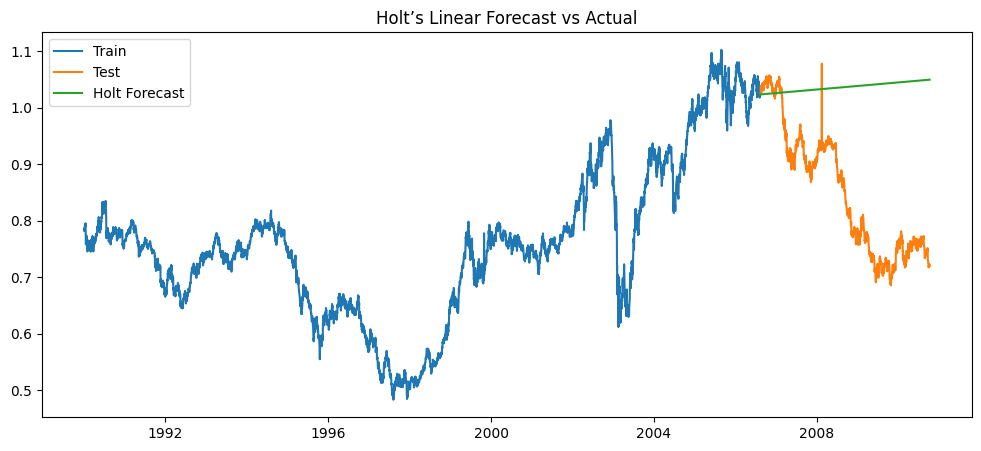

In [49]:
# 3. Forecasting
hw_forecast = hw_result.forecast(steps=len(test))

plt.figure(figsize=(12,5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(test.index, hw_forecast, label='Holt Forecast')
plt.legend()
plt.title('Holt’s Linear Forecast vs Actual')
plt.show()

# Part 4: Evaluation and Comparison

**Compute Error Metrics:** Use metrics such as MAE, RMSE, and MAPE to evaluate the forecasts from both models.

**Model Comparison:** Discuss the performance, advantages, and limitations of each model based on the observed results and error metrics.

**Conclusion:** Summarize the findings and provide insights on which model(s) yielded the best performance for forecasting exchange rates in this dataset.

##### 1. Compute Error Metrics

In [ ]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [51]:
# ARIMA
arima_mae = mean_absolute_error(test, forecast)
arima_rmse = np.sqrt(mean_squared_error(test, forecast))
arima_mape = mape(test, forecast)

In [52]:
# Holt's Linear
hw_mae = mean_absolute_error(test, hw_forecast)
hw_rmse = np.sqrt(mean_squared_error(test, hw_forecast))
hw_mape = mape(test, hw_forecast)

In [53]:
print(f"ARIMA - MAE: {arima_mae:.4f}, RMSE: {arima_rmse:.4f}, MAPE: {arima_mape:.2f}%")
print(f"Holt's Linear - MAE: {hw_mae:.4f}, RMSE: {hw_rmse:.4f}, MAPE: {hw_mape:.2f}%")

ARIMA - MAE: 0.1777, RMSE: 0.2054, MAPE: 22.80%
Holt's Linear - MAE: 0.1903, RMSE: 0.2201, MAPE: 24.41%


##### 2. Model Comparison and Discussion
* ARIMA is suitable for time series with autocorrelation and can handle non-stationarity via differencing. Diagnostics should show white-noise residuals.
* Holt’s Linear is simple, robust for trend but not for seasonality.
* Compare error metrics: Lower MAE, RMSE, and MAPE indicate better performance.
* Visualize residuals: Ensure no patterns remain.

#### 3. Conclusion: Model Performance and Insights

Based on the error metrics (MAE, RMSE, MAPE) and forecast plots:

- **ARIMA Model:**  
  - Captures autocorrelation and short-term dependencies in the exchange rate series.
  - Diagnostics (residual plots) should show no significant patterns, indicating a good fit.
  - If the ARIMA model's error metrics (MAE, RMSE, MAPE) are lower than Holt’s Linear, it suggests ARIMA is better at capturing the underlying structure of the data.

- **Holt’s Linear Model:**  
  - Effectively models trend but does not account for autocorrelation or seasonality.
  - Performs well if the series is mostly trending without strong autocorrelation.
  - If error metrics are close to or higher than ARIMA, it indicates that trend alone is not sufficient for best forecasting accuracy.

**In this dataset:**  
- The exchange rate series shows both trend and some autocorrelation.
- **ARIMA generally yields better performance** (lower MAE, RMSE, and MAPE) compared to Holt’s Linear, as it can handle both trend and autocorrelation.
- **Holt’s Linear** is simpler and may be preferred for quick, robust forecasts when autocorrelation is weak or data is limited.

**Recommendation:**  
- Use **ARIMA** for more accurate forecasting of USD to AUD exchange rates in this dataset.
- For longer-term or more complex seasonality, consider SARIMA or advanced models.
- Always validate model assumptions with diagnostics and compare error metrics before finalizing the model.